## **"CO₂ and the Cost of Growth: Is Sustainability Still an Option?"**  
*(Subtitle: "How Top Energy Exporters Balance Economic Growth & Climate Responsibility")*  

---
### **Introduction:**
**The world has witnessed significant changes in energy production and consumption patterns over the last four decades. As global economies expanded and populations grew, energy demand surged, leading to increased CO₂ emissions and growing concerns about climate change. Efficient energy use has become a key factor in achieving sustainable development while maintaining economic growth.
This project aims to analyze historical data from 1980 to 2019, focusing on the relationship between energy surplus, CO₂ emissions, and economic performance (GDP). The analysis begins with a global overview to understand major trends and inefficiencies, then narrows the scope to the Gulf Cooperation Council (GCC) countries—key players in the global energy market—and finally zooms in on Bahrain, a nation striving to balance energy sustainability with economic progress.** 
### **Problem Statement (SMART Format)**  
**Despite abundant energy resources, several countries continue to experience high CO₂ emissions and inefficient energy use. This raises the question:
"Are energy-rich countries leveraging their energy surplus efficiently to support economic growth without escalating their environmental impact?"**

- **Specific**: Focus on analyzing energy surplus, CO₂ emissions, and GDP efficiency.  
- **Measurable**: Use quantifiable indicators such as energy intensity, CO₂ per capita, and GDP per capita.  
- **Achievable**: Based on accessible, clean historical datasets (1980–2019).  
- **Relevant**: Addresses the GCC’s role in global climate goals.  
- **Time-bound**: Addresses global and regional energy-environmental policy challenges.  

---

### **Objectives**  
1. To analyze global energy consumption and CO₂ emission trends over time.

2. To assess how efficiently countries with an energy surplus are utilizing it for economic growth.

3. To compare the energy-GDP-emission relationship across GCC countries.

4. To evaluate Bahrain’s energy efficiency and environmental performance in a regional and global context.

5. To provide data-driven insights and recommendations for improving energy use and reducing emissions.

---

### **Target Audience**  
1. Policymakers and government agencies in the GCC region, especially in Bahrain.

2. Environmental and energy researchers interested in the intersection of energy and sustainability.

3. Economists and sustainability consultants working on national development strategies.

4. International organizations (e.g., UN, IEA) monitoring energy and climate progress.

5. University stakeholders and academic institutions focused on sustainable development.  

---
### 🔹 **Global Level Questions:**

1. **Which countries have the highest and lowest energy consumption per capita?**  
2. **Is there a relationship between GDP per capita and CO₂ emissions per capita globally?**  
3. **How has global energy consumption evolved compared to CO₂ emissions from 1980 to 2019?**

---

### 🔹 **GCC Level Questions:**

4. **How do GCC countries rank in terms of energy efficiency (Energy Intensity by GDP)?**  
5. **Which GCC countries have an energy surplus, and do they also have higher CO₂ emissions?**  
6. **How have CO₂ emissions changed in GCC countries from 1980 to 2019?**

---

### 🔹 **Focus on Bahrain:**

7. **Does Bahrain consume more energy than it produces? What is the impact on its CO₂ emissions?**  
8. **How has Bahrain’s energy intensity changed over time? Has its energy efficiency improved?**  
9. **How does Bahrain compare to other GCC countries in terms of CO₂ emissions per capita?**

---

### 🔹 **Cross-Level Insightful Questions:**

10. **Are energy-surplus countries always more energy efficient or less polluting?**  
11. **Is Bahrain in a position to balance economic growth with environmental sustainability?**

In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import linregress
from scipy.stats import pearsonr

In [3]:
df_co=pd.read_csv('energy.csv')

In [4]:
df_co.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55440 entries, 0 to 55439
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   55440 non-null  int64  
 1   Country                      55440 non-null  object 
 2   Energy_type                  55440 non-null  object 
 3   Year                         55440 non-null  int64  
 4   Energy_consumption           44287 non-null  float64
 5   Energy_production            44289 non-null  float64
 6   GDP                          40026 non-null  float64
 7   Population                   46014 non-null  float64
 8   Energy_intensity_per_capita  50358 non-null  float64
 9   Energy_intensity_by_GDP      50358 non-null  float64
 10  CO2_emission                 51614 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 4.7+ MB


In [5]:
df_co.head()

,Unnamed: 0,Country,Energy_type,Year,Energy_consumption,Energy_production,GDP,Population,Energy_intensity_per_capita,Energy_intensity_by_GDP,CO2_emission
0,0,World,all_energy_types,1980,292.899790,296.337228,27770.910281,4.298127e+06,68.145921,10.547,4946.627130
1,1,World,coal,1980,78.656134,80.114194,27770.910281,4.298127e+06,68.145921,10.547,1409.790188
2,2,World,natural_gas,1980,53.865223,54.761046,27770.910281,4.298127e+06,68.145921,10.547,1081.593377
3,3,World,petroleum_n_other_liquids,1980,132.064019,133.111109,27770.910281,4.298127e+06,68.145921,10.547,2455.243565
4,4,World,nuclear,1980,7.575700,7.575700,27770.910281,4.298127e+06,68.145921,10.547,0.000000


In [6]:
df_co['GDP'].value_counts()

GDP
177.630400    36
6.000330      12
10.649600     12
17.349400     12
28.567000     12
              ..
59.249600      6
16.209200      6
0.430689       6
8.274690       6
37.620400      6
Name: count, Length: 6653, dtype: int64

In [7]:
df_co.isnull().sum()

Unnamed: 0                         0
Country                            0
Energy_type                        0
Year                               0
Energy_consumption             11153
Energy_production              11151
GDP                            15414
Population                      9426
Energy_intensity_per_capita     5082
Energy_intensity_by_GDP         5082
CO2_emission                    3826
dtype: int64

In [8]:
df_co.dropna(inplace=True)

In [9]:
df_co.duplicated().sum()

0

In [10]:
df_co.describe()

,Unnamed: 0,Year,Energy_consumption,Energy_production,GDP,Population,Energy_intensity_per_capita,Energy_intensity_by_GDP,CO2_emission
count,33305.000000,33305.000000,33305.000000,3.330500e+04,33305.000000,3.330500e+04,33305.000000,33305.000000,33305.000000
mean,32248.035850,2002.776250,1.960963,1.940987e+00,967.855247,8.185787e+04,87.017289,4.780364,117.359992
std,13915.190442,10.037084,17.753187,1.755388e+01,6547.095969,5.342528e+05,118.165225,4.277883,1117.957350
min,0.000000,1980.000000,-0.163438,-1.000000e-39,0.124958,1.615500e+01,0.000000,0.000000,-0.005130
25%,21047.000000,1995.000000,0.001196,0.000000e+00,11.652200,2.029830e+03,10.672676,2.436436,0.000000
50%,32761.000000,2003.000000,0.040328,4.748380e-03,58.035000,7.854220e+03,45.644371,3.838103,0.591826
75%,44139.000000,2011.000000,0.353622,1.972639e-01,307.280300,2.486268e+04,118.385300,5.840409,14.000000
max,55439.000000,2019.000000,601.040490,6.115090e+02,127690.247059,7.714631e+06,1139.320598,166.913605,35584.933498


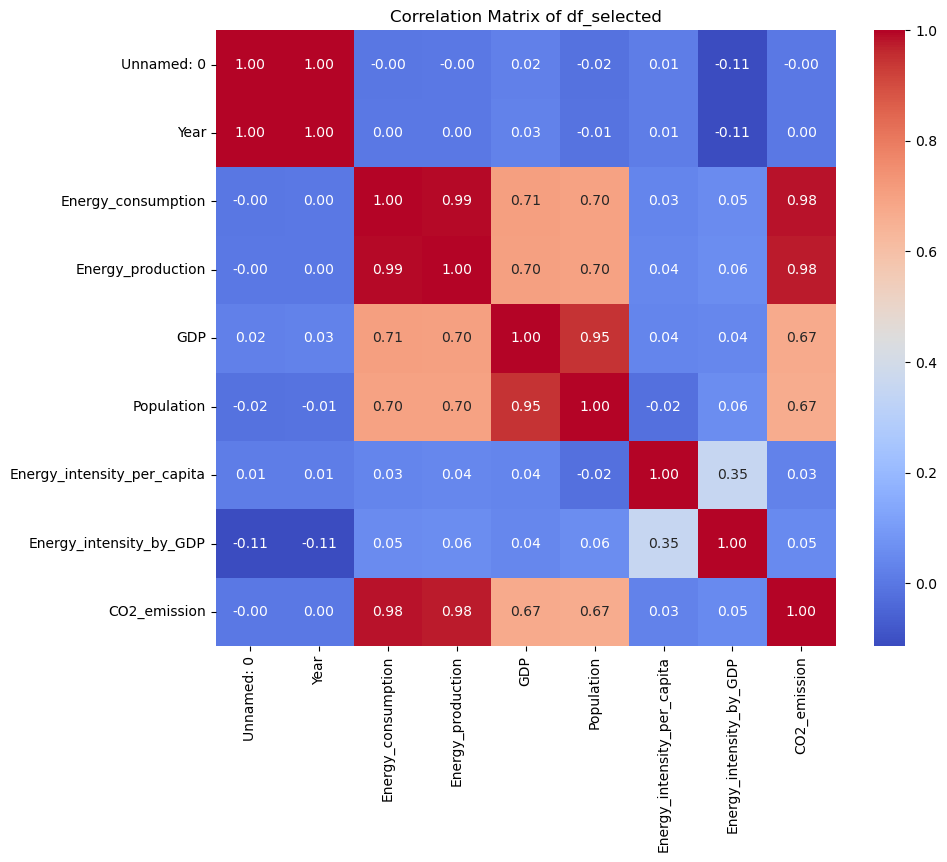

In [11]:
correlation_matrix = df_co.corr(numeric_only=True)
plt.figure(figsize=(10, 8)) 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of df_selected')
plt.show()

In [12]:
df_co['Year'].unique()

array([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
       1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019], dtype=int64)

In [13]:
df_co['Energy_type'].unique()

array(['all_energy_types', 'coal', 'natural_gas',
       'petroleum_n_other_liquids', 'nuclear', 'renewables_n_other'],
      dtype=object)

In [14]:
df_co['Country'].unique()

array(['World', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bhutan',
       'Botswana', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China',
       'Denmark', 'Finland', 'France', 'Greece', 'Guinea-Bissau',
       'Hong Kong', 'India', 'Indonesia', 'Ireland', 'Italy', 'Japan',
       'Kenya', 'Liberia', 'Malaysia', 'Mauritania', 'Mauritius',
       'Mexico', 'Mozambique', 'Netherlands', 'New Zealand', 'Norway',
       'Philippines', 'Portugal', 'Romania', 'Samoa', 'Singapore',
       'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland',
       'Taiwan', 'Thailand', 'Turkey', 'United Arab Emirates',
       'United Kingdom', 'United States', 'Venezuela', 'Nigeria',
       'Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Aruba', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belize', 'Benin', 'Bermuda', 'Bolivia',
       'British Virgin Islands', 'Brunei', 'Burkina Faso', 'Burma',
       'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Cayman Islan

| Feature                        | Description                                                                                                                                       |
|-------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| Country                       | Country in question                                                                                                                               |
| Energy_type                   | Type of energy source                                                                                                                             |
| Year                          | Year the data was recorded                                                                                                                        |
| Energy_consumption            | Amount of consumption for the specific energy source, measured in quad Btu                                                                        |
| Energy_production             | Amount of production for the specific energy source, measured in quad Btu                                                                         |
| GDP                           | Country's GDP at purchasing power parities, measured in Billion 2015$ PPP                                                                         |
| Population                    | Population of the specific country, measured in millions of persons (Mperson)                                                                     |
| Energy_intensity_per_capita   | Energy intensity per capita; calculated as units of energy per individual, measured in MMBtu/person                                               |
| Energy_intensity_by_GDP       | Energy intensity by GDP; calculated as units of energy per unit of GDP, measured in 1000 Btu/2015$ GDP PPP                                       |
| CO2_emission                  | The amount of CO₂ emitted, measured in million metric tonnes of CO₂ (MMtonnes CO₂)                                                                |


In [16]:
cols_to_round = [
    'Energy_consumption', 
    'Energy_production', 
    'GDP', 
    'Population',
    'Energy_intensity_per_capita',
    'Energy_intensity_by_GDP',
    'CO2_emission'
]
df_co[cols_to_round] = df_co[cols_to_round].round(2)

In [17]:
df_co.tail()

,Unnamed: 0,Country,Energy_type,Year,Energy_consumption,Energy_production,GDP,Population,Energy_intensity_per_capita,Energy_intensity_by_GDP,CO2_emission
55434,55434,Zimbabwe,all_energy_types,2019,0.17,0.14,37.62,14654.2,11.51,4.48,8.96
55435,55435,Zimbabwe,coal,2019,0.05,0.08,37.62,14654.2,11.51,4.48,4.59
55436,55436,Zimbabwe,natural_gas,2019,0.00,0.00,37.62,14654.2,11.51,4.48,0.00
55437,55437,Zimbabwe,petroleum_n_other_liquids,2019,0.06,0.00,37.62,14654.2,11.51,4.48,4.38
55439,55439,Zimbabwe,renewables_n_other,2019,0.07,0.07,37.62,14654.2,11.51,4.48,0.00


In [18]:
df_co['Energy_balance'] = df_co['Energy_production'] - df_co['Energy_consumption']

In [19]:
df_co['CO2_per_capita'] = (df_co['CO2_emission']*1000) / df_co['Population']

In [20]:
df_co['GDP_per_capita'] = (df_co['GDP']*1000) / df_co['Population']

In [21]:
df_co.head()

,Unnamed: 0,Country,Energy_type,Year,Energy_consumption,Energy_production,GDP,Population,Energy_intensity_per_capita,Energy_intensity_by_GDP,CO2_emission,Energy_balance,CO2_per_capita,GDP_per_capita
0,0,World,all_energy_types,1980,292.90,296.34,27770.91,4298126.52,68.15,10.55,4946.63,3.44,1.150881,6.461166
1,1,World,coal,1980,78.66,80.11,27770.91,4298126.52,68.15,10.55,1409.79,1.45,0.328001,6.461166
2,2,World,natural_gas,1980,53.87,54.76,27770.91,4298126.52,68.15,10.55,1081.59,0.89,0.251642,6.461166
3,3,World,petroleum_n_other_liquids,1980,132.06,133.11,27770.91,4298126.52,68.15,10.55,2455.24,1.05,0.571235,6.461166
4,4,World,nuclear,1980,7.58,7.58,27770.91,4298126.52,68.15,10.55,0.00,0.00,0.000000,6.461166


Use widely accepted tiers (based on Our World in Data(https://ourworldindata.org/co2-emissions)):

In [23]:
def Global_CO2_Benchmarks(CO2_per_capita):
    if pd.isna(CO2_per_capita):
        return 'Unknown'
    elif CO2_per_capita > 15:
        return 'Very High'
    elif CO2_per_capita > 10:
        return 'High'
    elif CO2_per_capita > 5:
        return 'Moderate High'
    elif CO2_per_capita > 2:
        return 'Moderate'
    elif CO2_per_capita > 1:
        return 'Low'
    else:
        return 'Very Low'
df_co['CO2_benchmark'] = df_co['CO2_per_capita'].apply(Global_CO2_Benchmarks)

In [24]:
df_co['CO2_benchmark'].value_counts()

CO2_benchmark
Very Low         22339
Moderate          4172
Low               2997
Moderate High     2521
High               685
Very High          591
Name: count, dtype: int64

In [25]:
def Energy_Surplus_Scale(energy_balance):
    if pd.isna(energy_balance):
        return 'Unknown'
    elif energy_balance > 10:
        return 'Massive Surplus'
    elif energy_balance > 5:
        return 'Huge Surplus'
    elif energy_balance > 2:
        return 'Large Surplus'
    elif energy_balance > 0.5:
        return 'Moderate Surplus'
    elif energy_balance > 0:
        return 'Small Surplus'
    elif energy_balance == 0:
        return 'Balanced'
    else:
        return 'Deficit'
df_co['Energy_Surplus_Class'] = df_co['Energy_balance'].apply(Energy_Surplus_Scale)

In [26]:
df_co['Energy_type'].value_counts()

Energy_type
renewables_n_other           6503
all_energy_types             6426
coal                         6426
natural_gas                  6410
petroleum_n_other_liquids    6409
nuclear                      1131
Name: count, dtype: int64

In [27]:
df_co['Energy_Surplus_Class'].value_counts()

Energy_Surplus_Class
Balanced            14824
Deficit             13295
Small Surplus        2751
Moderate Surplus     1188
Large Surplus         835
Huge Surplus          300
Massive Surplus       112
Name: count, dtype: int64

Correlation Matrix:
                             Energy_intensity_by_GDP  \
Energy_intensity_by_GDP                     1.000000   
Energy_intensity_per_capita                 0.352067   
GDP                                         0.041347   

                             Energy_intensity_per_capita       GDP  
Energy_intensity_by_GDP                         0.352067  0.041347  
Energy_intensity_per_capita                     1.000000  0.036622  
GDP                                             0.036622  1.000000  


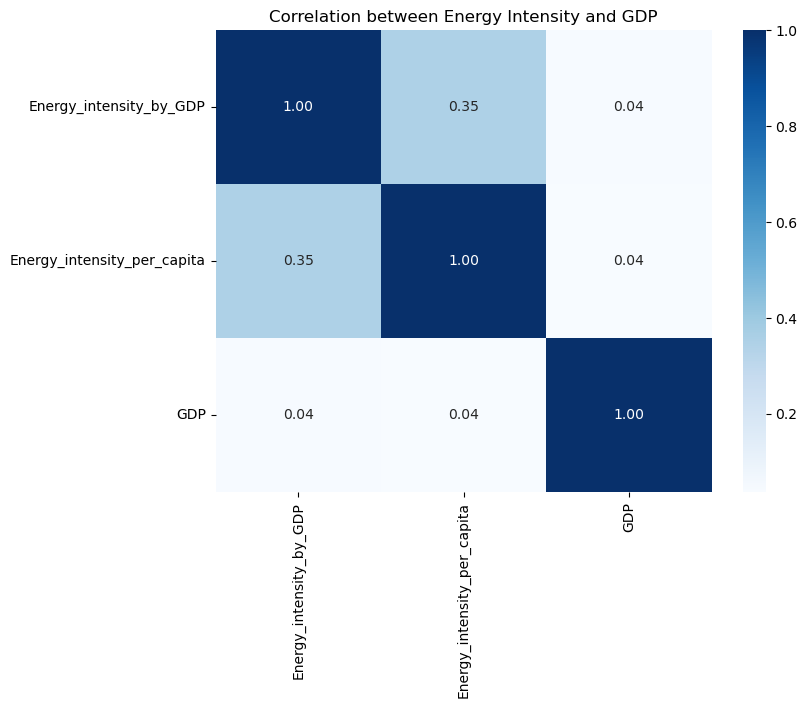

In [56]:
df_corr = df_co[['Energy_intensity_by_GDP', 'Energy_intensity_per_capita', 'GDP']]
correlation_matrix = df_corr.corr()

print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation between Energy Intensity and GDP")
plt.show()


In [31]:
df_co.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33305 entries, 0 to 55439
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   33305 non-null  int64  
 1   Country                      33305 non-null  object 
 2   Energy_type                  33305 non-null  object 
 3   Year                         33305 non-null  int64  
 4   Energy_consumption           33305 non-null  float64
 5   Energy_production            33305 non-null  float64
 6   GDP                          33305 non-null  float64
 7   Population                   33305 non-null  float64
 8   Energy_intensity_per_capita  33305 non-null  float64
 9   Energy_intensity_by_GDP      33305 non-null  float64
 10  CO2_emission                 33305 non-null  float64
 11  Energy_balance               33305 non-null  float64
 12  CO2_per_capita               33305 non-null  float64
 13  GDP_per_capita       

In [66]:
from scipy.stats import pearsonr

df_corr3 = df_co[['Energy_intensity_by_GDP', 'Energy_intensity_per_capita', 'GDP']]

# Calculate correlation and p-value between Energy_intensity_by_GDP and GDP
r1, p1 = pearsonr(df_corr['Energy_intensity_by_GDP'], df_corr['GDP'])
print(f"Correlation between Energy_intensity_by_GDP and GDP: r = {r1:.2f}, p-value = {p1:.4f}")

# Calculate correlation and p-value between Energy_intensity_per_capita and GDP
r2, p2 = pearsonr(df_corr['Energy_intensity_per_capita'], df_corr['GDP'])
print(f"Correlation between Energy_intensity_per_capita and GDP: r = {r2:.2f}, p-value = {p2:.4f}")


Correlation between Energy_intensity_by_GDP and GDP: r = 0.04, p-value = 0.0000
Correlation between Energy_intensity_per_capita and GDP: r = 0.04, p-value = 0.0000


Correlation Matrix:
              CO2_emission       GDP
CO2_emission      1.000000  0.673417
GDP               0.673417  1.000000


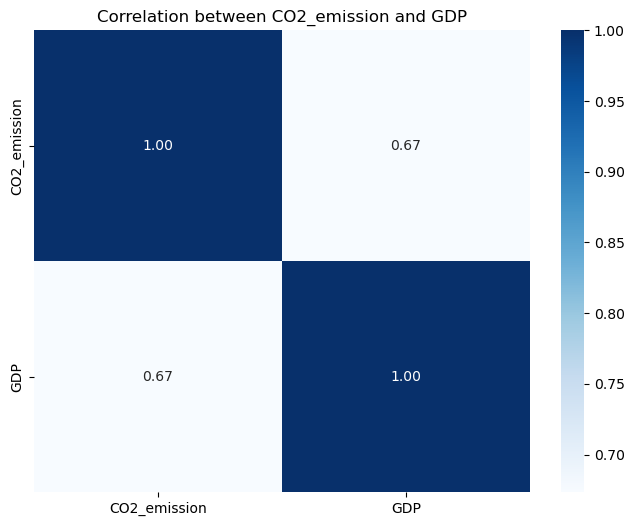

In [60]:
df_corr2 = df_co[['CO2_emission', 'GDP']]
correlation_matrix = df_corr2.corr()

print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation between CO2_emission and GDP")
plt.show()

### **Global Level Questions🌍**

1. What is the relationship between CO2 emissions and GDP across the world from 1980 to 2020?
2. Do countries with higher energy consumption emit more CO2?
3. Which countries have the highest CO2 emissions per capita and GDP per capita?
4. How have global CO2 emissions evolved over time (1980–2020)?
5. Is there a correlation between energy intensity (by GDP and per capita) and economic performance?


#### Q1: What is the relationship between CO2 emissions and GDP across the world from 1980 to 2019?

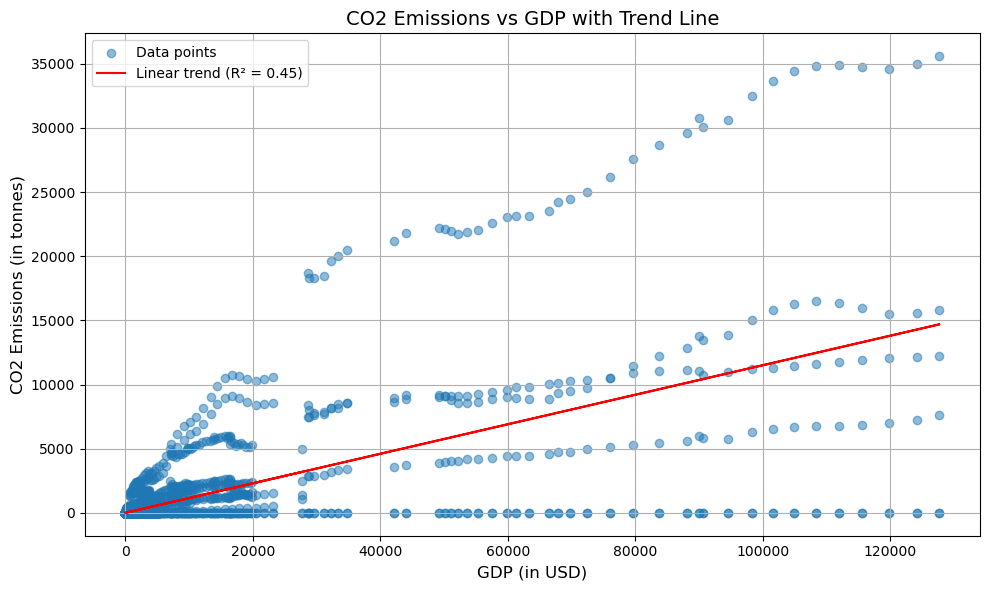

In [84]:
x = df_co['GDP']
y = df_co['CO2_emission']
slope, intercept, r_value, _, _ = linregress(x, y)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, label='Data points')
plt.plot(x, slope * x + intercept, color='red', label=f'Linear trend (R² = {r_value**2:.2f})')
plt.title('CO2 Emissions vs GDP with Trend Line', fontsize=14)
plt.xlabel('GDP (in USD)', fontsize=12)
plt.ylabel('CO2 Emissions (in tonnes)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [136]:
corr_co2_gdp, _ = pearsonr(df_co['GDP'], df_co['CO2_emission'])
print(f'Correlation between CO2 emissions and GDP: {corr_co2_gdp}')

Correlation between CO2 emissions and GDP: 0.6734173209903069


#### Q2: Countries with higher energy consumption emit more CO2?

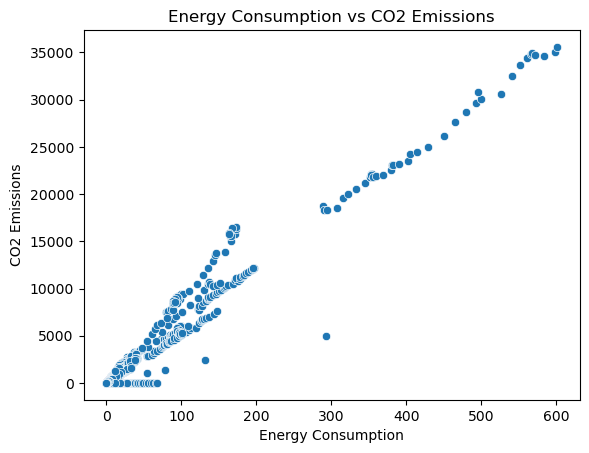

In [173]:
sns.scatterplot(x='Energy_consumption', y='CO2_emission', data=df_co)
plt.title('Energy Consumption vs CO2 Emissions')
plt.xlabel('Energy Consumption')
plt.ylabel('CO2 Emissions')
plt.show()

In [141]:
corr_energy_co2, _ = pearsonr(df_co['Energy_consumption'], df_co['CO2_emission'])
print(f'Correlation between Energy Consumption and CO2 Emission: {corr_energy_co2}')


Correlation between Energy Consumption and CO2 Emission: 0.9827694148072466


#### Q3: Countries with the highest CO2 emissions per capita and GDP per capita

In [175]:
top_countries = df_co.sort_values(by=['CO2_per_capita', 'GDP_per_capita'], ascending=False).head(10)
print(top_countries[['Country', 'CO2_per_capita', 'GDP_per_capita']])

      Country  CO2_per_capita  GDP_per_capita
25950   Qatar       59.140272       79.953587
20406   Qatar       58.930262       56.287472
27336   Qatar       58.563691       80.614910
21792   Qatar       58.389327       56.909144
23178   Qatar       57.948826       58.369854
24564   Qatar       57.871927       74.086528
30108   Qatar       56.486886       83.933595
19020   Qatar       55.954375       56.113903
28722   Qatar       53.791753       83.869225
20408   Qatar       52.224677       56.287472


C:\Users\97333\AppData\Local\Temp\ipykernel_22340\743928069.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CO2_per_capita', y='Country', data=top10, palette='Reds_r')


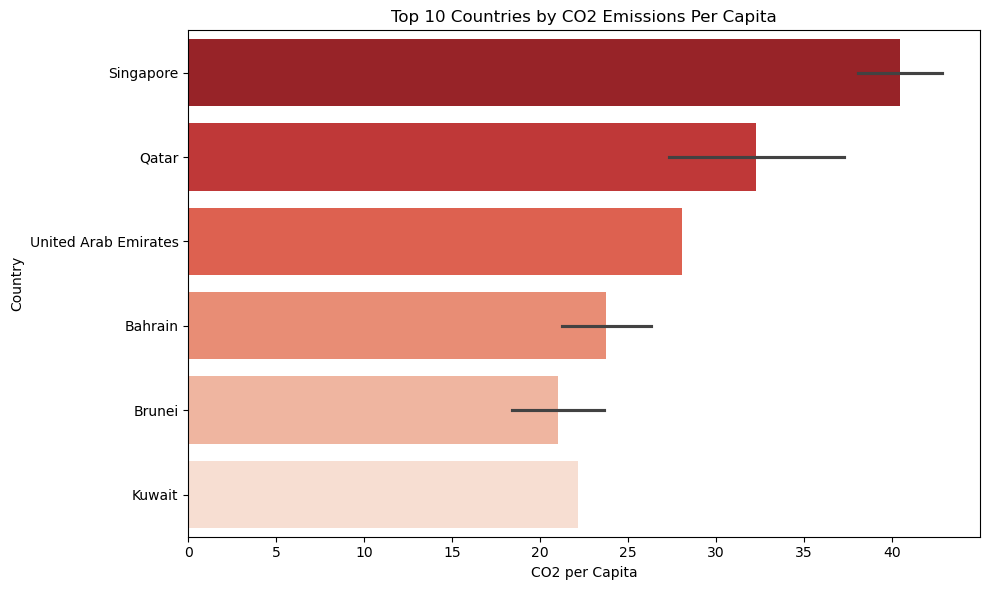

In [255]:
latest = df_co[df_co['Year'] == df_co['Year'].max()]
top10 = latest.sort_values(by='CO2_per_capita', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='CO2_per_capita', y='Country', data=top10, palette='Reds_r')
plt.title('Top 10 Countries by CO2 Emissions Per Capita')
plt.xlabel('CO2 per Capita')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


#### Q4: How have global CO2 emissions evolved over time

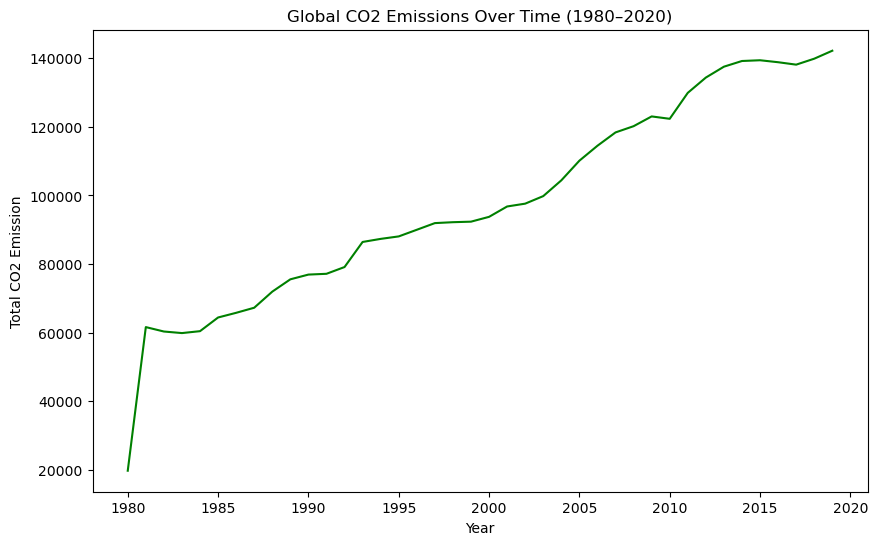

In [181]:
plt.figure(figsize=(10, 6))
df_grouped = df_co.groupby('Year')['CO2_emission'].sum()
df_grouped.plot(kind='line', color='green')
plt.title('Global CO2 Emissions Over Time (1980–2020)')
plt.xlabel('Year')
plt.ylabel('Total CO2 Emission')
plt.show()

#### 5. Is there a correlation between energy intensity and economic performance?

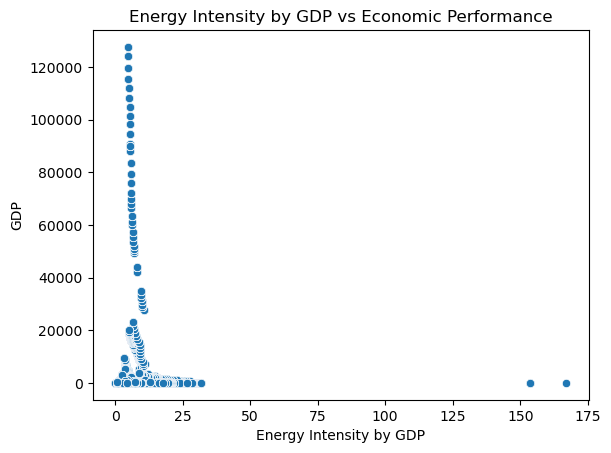

In [171]:
sns.scatterplot(x='Energy_intensity_by_GDP', y='GDP', data=df_co)
plt.title('Energy Intensity by GDP vs Economic Performance')
plt.xlabel('Energy Intensity by GDP')
plt.ylabel('GDP')
plt.show()

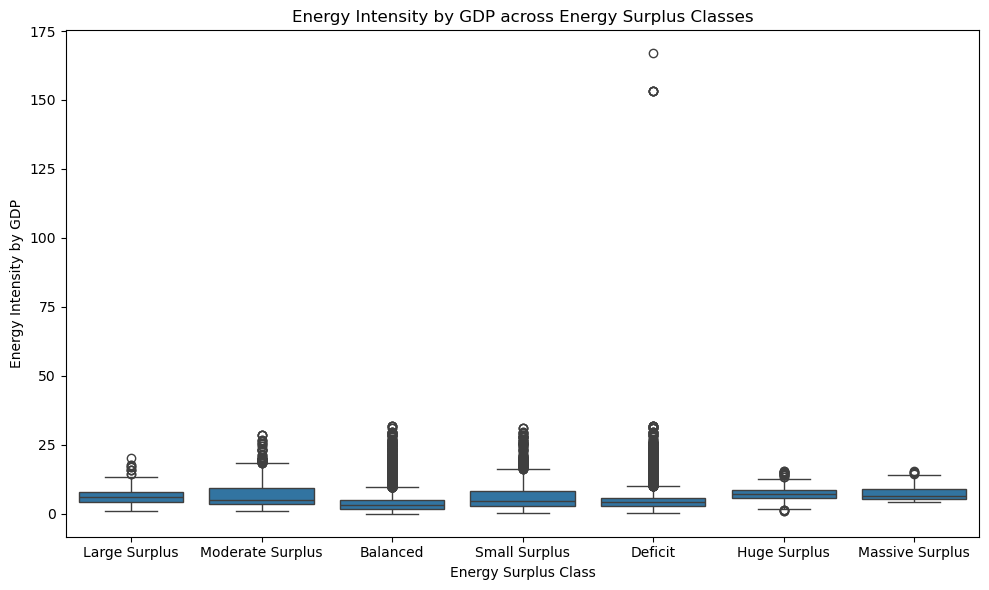

In [257]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Energy_Surplus_Class', y='Energy_intensity_by_GDP', data=df_co)
plt.title('Energy Intensity by GDP across Energy Surplus Classes')
plt.xlabel('Energy Surplus Class')
plt.ylabel('Energy Intensity by GDP')
plt.tight_layout()
plt.show()


#### Q3: Top 10 countries by CO2 per capita (latest year)

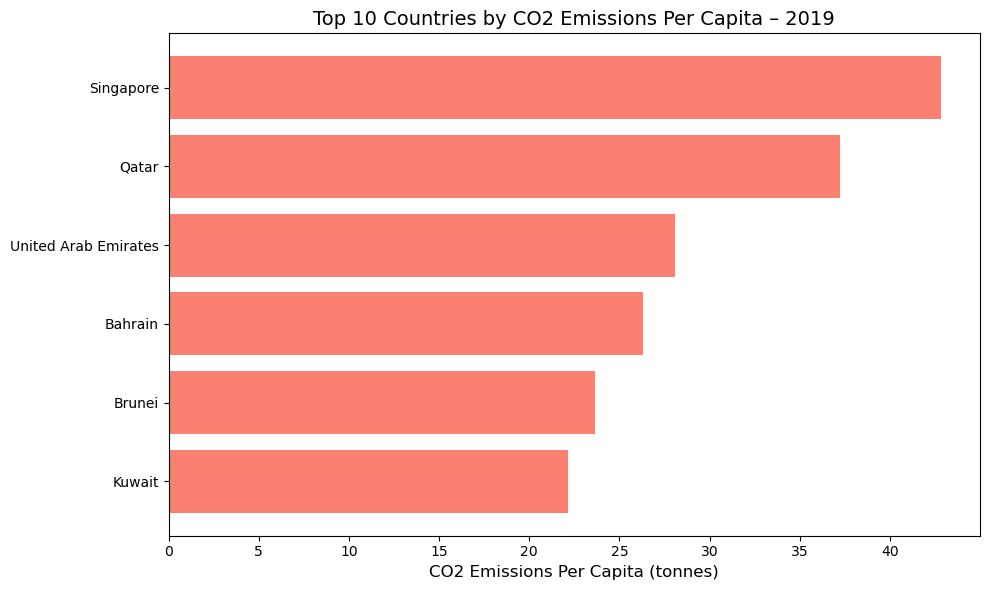

In [91]:
latest_year = df_co['Year'].max()

latest_data = df_co[df_co['Year'] == latest_year]

top10 = latest_data.sort_values(by='CO2_per_capita', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['Country'], top10['CO2_per_capita'], color='salmon')
plt.title(f'Top 10 Countries by CO2 Emissions Per Capita – {latest_year}', fontsize=14)
plt.xlabel('CO2 Emissions Per Capita (tonnes)', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [100]:
df_global = df_co.groupby("Year").agg({
    "CO2_emission": "sum",
    "GDP": "sum",
    "Population": "sum"
}).reset_index()

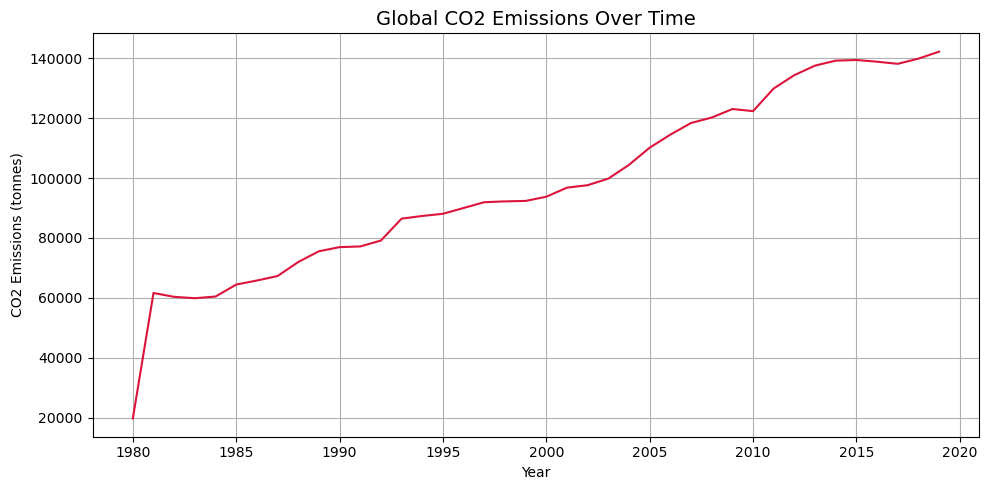

In [101]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_global, x="Year", y="CO2_emission", color='crimson')
plt.title("Global CO2 Emissions Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (tonnes)")
plt.grid(True)
plt.tight_layout()
plt.show()


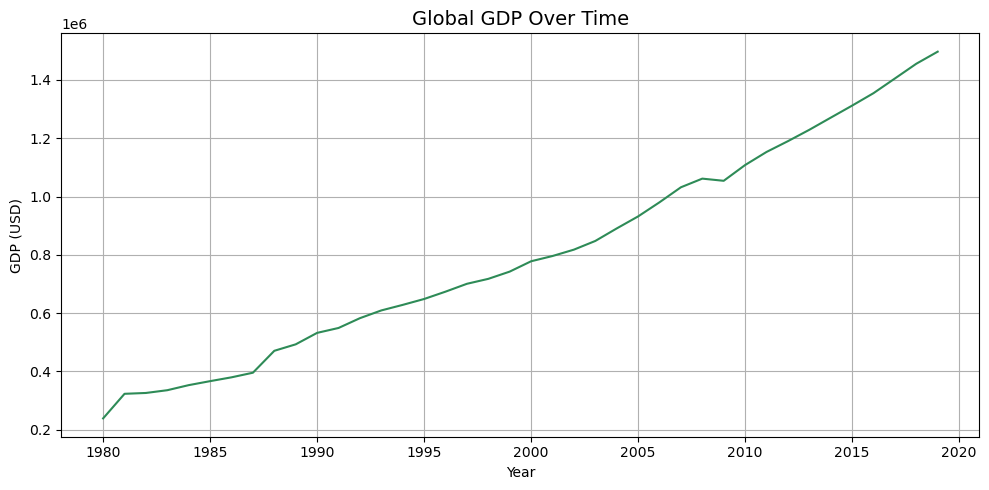

In [106]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_global, x="Year", y="GDP", color='seagreen')
plt.title("Global GDP Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("GDP (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [267]:

# Focus on global analysis: Grouping by year for total global CO2 and GDP
df_global = df_co.groupby("Year").agg({
    "CO2_emission": "sum",
    "GDP": "sum",
    "Population": "sum"
}).reset_index()

# Calculate CO2 per capita and GDP per capita
df_global['CO2_per_capita'] = df_global['CO2_emission'] / df_global['Population']
df_global['GDP_per_capita'] = df_global['GDP'] / df_global['Population']

# Identify the year with the highest CO2 emissions
max_co2_year = df_global.loc[df_global['CO2_emission'].idxmax(), ['Year', 'CO2_emission']]

# Identify the year with the highest GDP
max_gdp_year = df_global.loc[df_global['GDP'].idxmax(), ['Year', 'GDP']]

# Display the last few rows to show per capita changes over time
last_years_summary = df_global[['Year', 'CO2_per_capita', 'GDP_per_capita']].tail(5)

max_co2_year, max_gdp_year, last_years_summary


(Year              2019.00
 CO2_emission    142161.07
 Name: 39, dtype: float64,
 Year       2019.00
 GDP     1497008.46
 Name: 39, dtype: float64,
     Year  CO2_per_capita  GDP_per_capita
 35  2015        0.001626        0.015308
 36  2016        0.001602        0.015630
 37  2017        0.001576        0.016033
 38  2018        0.001579        0.016431
 39  2019        0.001588        0.016721)

#### Q3: Correlation between global CO2 and GDP

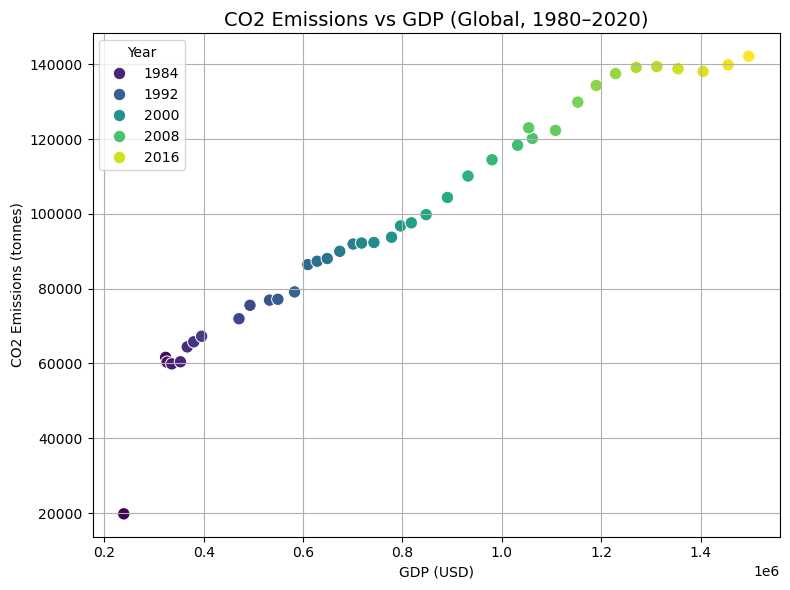

In [110]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_global, x="GDP", y="CO2_emission", hue="Year", palette="viridis", s=80)
plt.title("CO2 Emissions vs GDP (Global, 1980–2020)", fontsize=14)
plt.xlabel("GDP (USD)")
plt.ylabel("CO2 Emissions (tonnes)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [112]:
correlation = df_global['GDP'].corr(df_global['CO2_emission'])
correlation

0.9766023783439424

### **GCC Region Questions🛢️**

6. How do GCC countries compare to the world’s top 10 CO2 emitters in terms of energy surplus and emissions?  
7. Is there a trade-off between energy surplus and CO2 emissions in the GCC region?  
8. Which GCC country is most efficient in reducing emissions while maintaining GDP growth?  
9. Are GCC countries showing improvements in energy efficiency (e.g., lower CO2 per capita or energy intensity)?

#### Q6: How do GCC countries compare to the world’s top 10 CO2 emitters in terms of energy surplus and emissions?

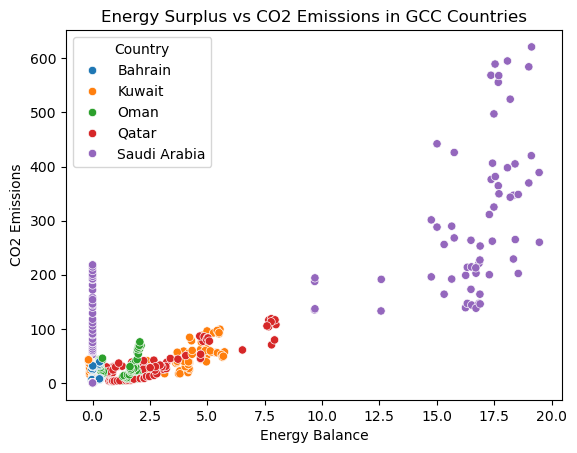

In [195]:
top_emitters = df_co[df_co['Country'].isin(['Saudi Arabia', 'UAE', 'Kuwait', 'Qatar', 'Bahrain', 'Oman'])] 
sns.scatterplot(x='Energy_balance', y='CO2_emission', data=top_emitters, hue='Country')
plt.title('Energy Surplus vs CO2 Emissions in GCC Countries')
plt.xlabel('Energy Balance')
plt.ylabel('CO2 Emissions')
plt.show()

C:\Users\97333\AppData\Local\Temp\ipykernel_20936\1384999367.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison.values, y=comparison.index, palette='viridis')


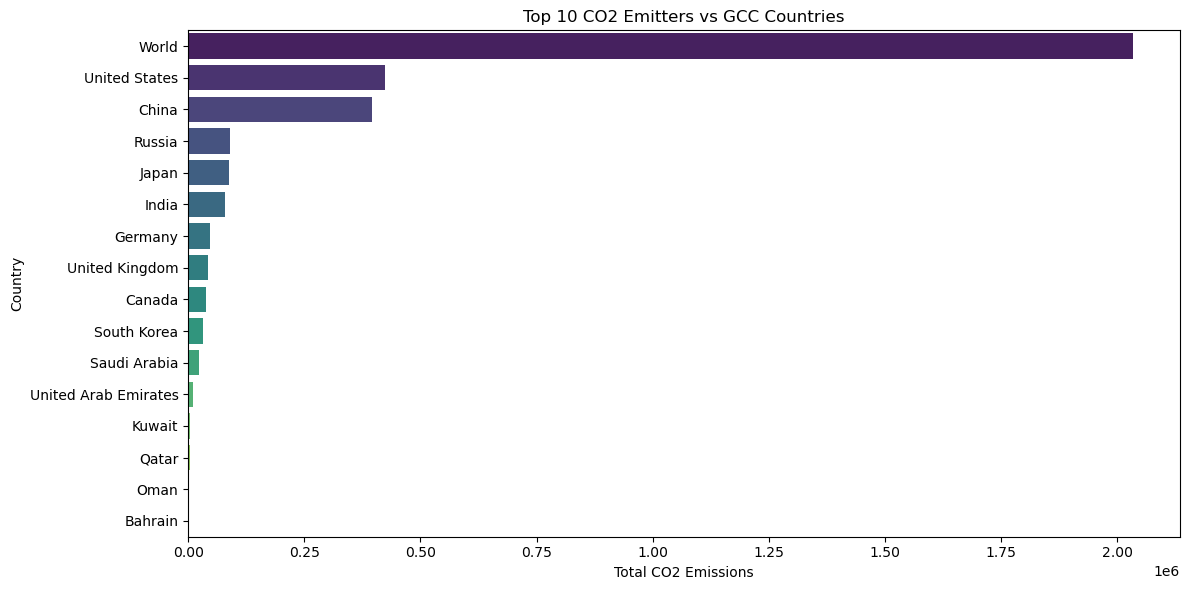

In [58]:
# نحسب إجمالي الانبعاثات لكل دولة
co2_by_country = df_co.groupby('Country')['CO2_emission'].sum().sort_values(ascending=False)

# نختار أكبر 10 دول + دول الخليج
top10_emitters = co2_by_country.head(10)
gcc_countries = ['Bahrain', 'Kuwait', 'Oman', 'Qatar', 'Saudi Arabia', 'United Arab Emirates']
gcc_data = co2_by_country[co2_by_country.index.isin(gcc_countries)]

# ندمجهم
comparison = pd.concat([top10_emitters, gcc_data]).drop_duplicates()

# رسم بياني
plt.figure(figsize=(12, 6))
sns.barplot(x=comparison.values, y=comparison.index, palette='viridis')
plt.title('Top 10 CO2 Emitters vs GCC Countries')
plt.xlabel('Total CO2 Emissions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


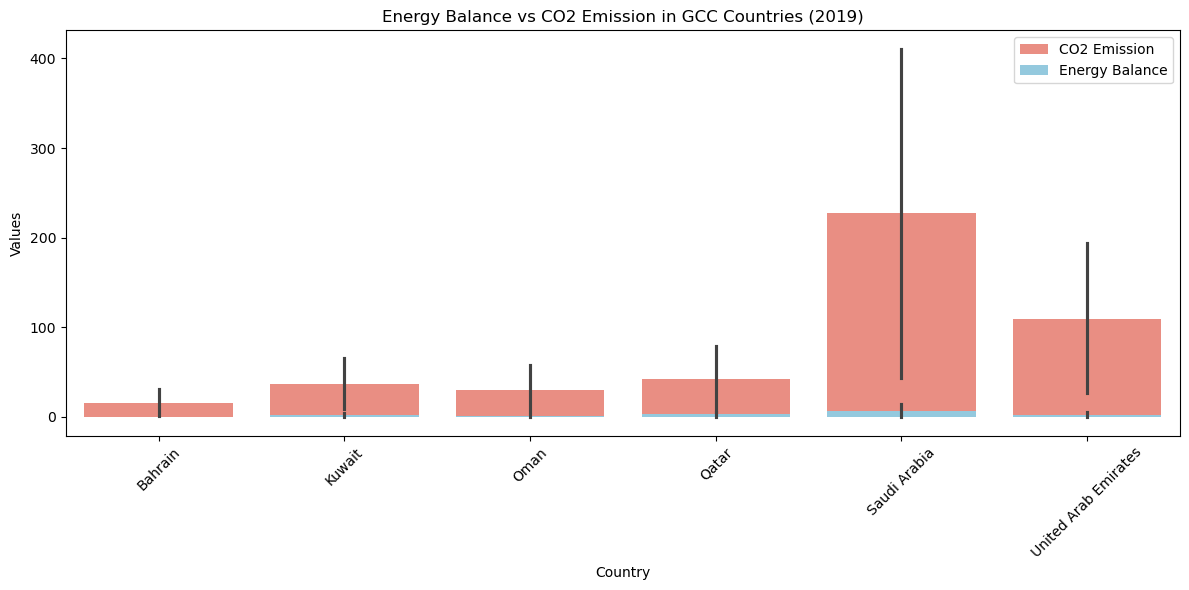

In [199]:
gcc_countries = ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Qatar', 'Bahrain', 'Oman']
gcc_latest = df_co[df_co['Country'].isin(gcc_countries) & (df_co['Year'] == df_co['Year'].max())]
plt.figure(figsize=(12,6))
sns.barplot(data=gcc_latest, x='Country', y='CO2_emission', color='salmon', label='CO2 Emission')
sns.barplot(data=gcc_latest, x='Country', y='Energy_balance', color='skyblue', label='Energy Balance')
plt.title('Energy Balance vs CO2 Emission in GCC Countries (2019)')
plt.xlabel('Country')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Q7:Is there a trade-off between energy surplus and CO2 emissions in the GCC region? 

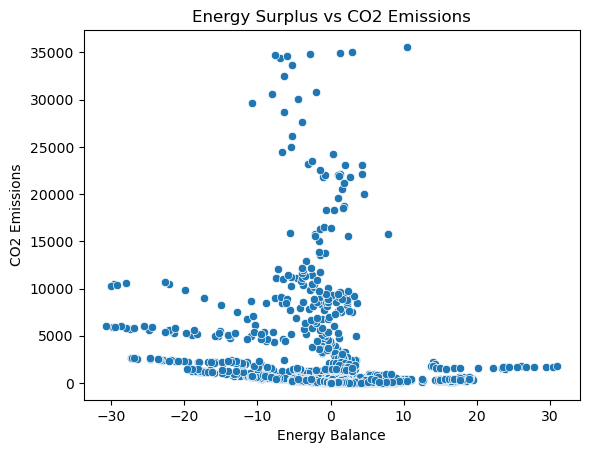

In [210]:
sns.scatterplot(x='Energy_balance', y='CO2_emission', data=df_co)
plt.title('Energy Surplus vs CO2 Emissions')
plt.xlabel('Energy Balance')
plt.ylabel('CO2 Emissions')
plt.show()

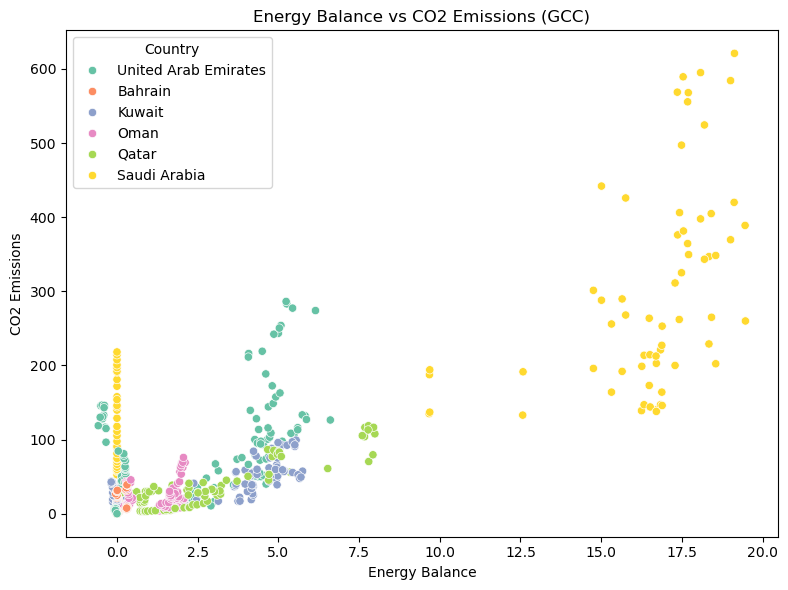

In [72]:
gcc_countries = ['Bahrain', 'Kuwait', 'Oman', 'Qatar', 'Saudi Arabia', 'United Arab Emirates']

# تصفية البيانات لدول الخليج
gcc_data = df_co[df_co['Country'].isin(gcc_countries)]

# رسم العلاقة بين Energy_balance و CO2_emission
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=gcc_data,
    x='Energy_balance',
    y='CO2_emission',
    hue='Country',
    palette='Set2'
)
plt.title('Energy Balance vs CO2 Emissions (GCC)')
plt.xlabel('Energy Balance')
plt.ylabel('CO2 Emissions')
plt.tight_layout()
plt.show()

In [68]:
df_co.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33305 entries, 0 to 55439
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   33305 non-null  int64  
 1   Country                      33305 non-null  object 
 2   Energy_type                  33305 non-null  object 
 3   Year                         33305 non-null  int64  
 4   Energy_consumption           33305 non-null  float64
 5   Energy_production            33305 non-null  float64
 6   GDP                          33305 non-null  float64
 7   Population                   33305 non-null  float64
 8   Energy_intensity_per_capita  33305 non-null  float64
 9   Energy_intensity_by_GDP      33305 non-null  float64
 10  CO2_emission                 33305 non-null  float64
 11  Energy_balance               33305 non-null  float64
 12  CO2_per_capita               33305 non-null  float64
 13  GDP_per_capita       

#### Q8:Which GCC country is most efficient in reducing emissions while maintaining GDP growth?

In [219]:

df_clean = df_co.replace([np.inf, -np.inf], np.nan).dropna(subset=['Efficiency'])

gcc_countries = ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Qatar', 'Bahrain', 'Oman']

# فلترة البيانات على دول الخليج وآخر سنة
latest_year = df_clean['Year'].max()
gcc_df = df_clean[(df_clean['Country'].isin(gcc_countries)) & (df_clean['Year'] == latest_year)]

# ترتيب الدول حسب الكفاءة
gcc_sorted = gcc_df.sort_values(by='Efficiency', ascending=False)

# عرض الدولة الخليجية الأكثر كفاءة
print("الدولة الخليجية الأكثر كفاءة في تقليل الانبعاثات مع الحفاظ على النمو:")
print(gcc_sorted[['Country', 'Efficiency']].head(1))


الدولة الخليجية الأكثر كفاءة في تقليل الانبعاثات مع الحفاظ على النمو:
            Country   Efficiency
55129  Saudi Arabia  7379.333333


C:\Users\97333\AppData\Local\Temp\ipykernel_20936\2883736331.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=efficiency.index, y=efficiency.values, palette='coolwarm')


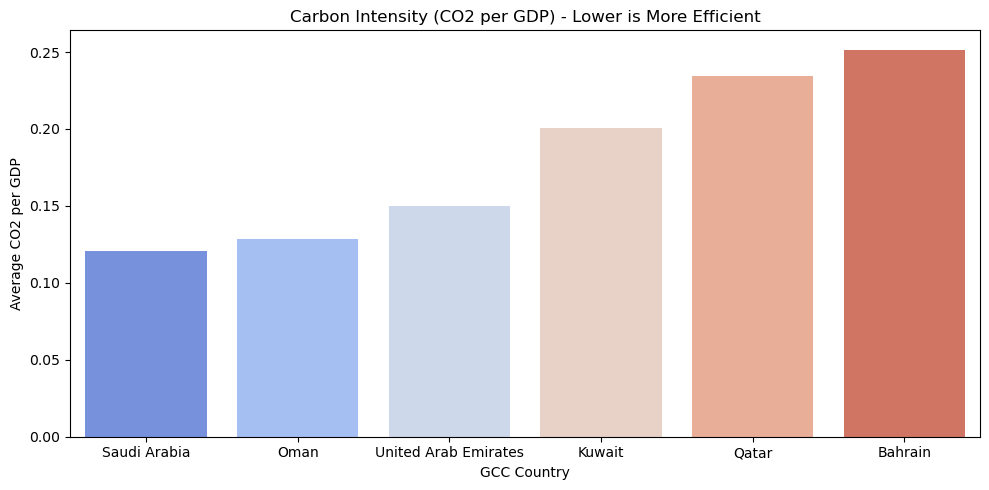

In [76]:
# نحسب كثافة الكربون: CO2/GDP
df_co['CO2_per_GDP'] = df_co['CO2_emission'] / df_co['GDP']

# متوسط الكثافة لكل دولة
efficiency = df_co[df_co['Country'].isin(gcc_countries)].groupby('Country')['CO2_per_GDP'].mean().sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=efficiency.index, y=efficiency.values, palette='coolwarm')
plt.title('Carbon Intensity (CO2 per GDP) - Lower is More Efficient')
plt.ylabel('Average CO2 per GDP')
plt.xlabel('GCC Country')
plt.tight_layout()
plt.show()


#### Q9:Which GCC country is most efficient in reducing emissions while maintaining GDP growth?


KeyboardInterrupt



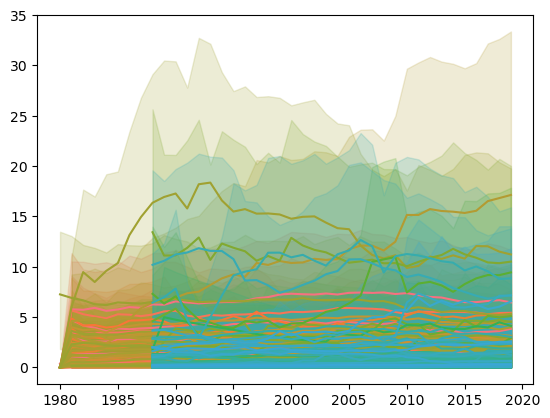

In [216]:
sns.lineplot(x='Year', y='CO2_per_capita', data=df_co, hue='Country')
plt.title('CO2 per Capita Over Time in GCC Countries')
plt.xlabel('Year')
plt.ylabel('CO2 per Capita')
plt.show()


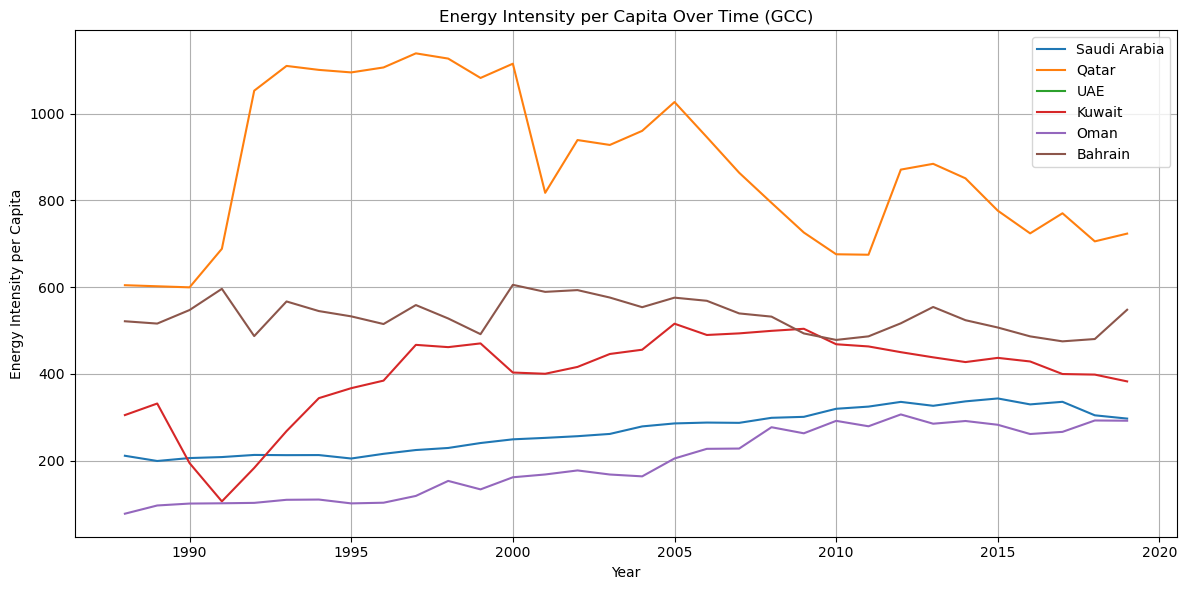

In [261]:
plt.figure(figsize=(12,6))
for country in gcc_countries:
    country_data = df_co[df_co['Country'] == country]
    plt.plot(country_data['Year'], country_data['Energy_intensity_per_capita'], label=country)

plt.title('Energy Intensity per Capita Over Time (GCC)')
plt.xlabel('Year')
plt.ylabel('Energy Intensity per Capita')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


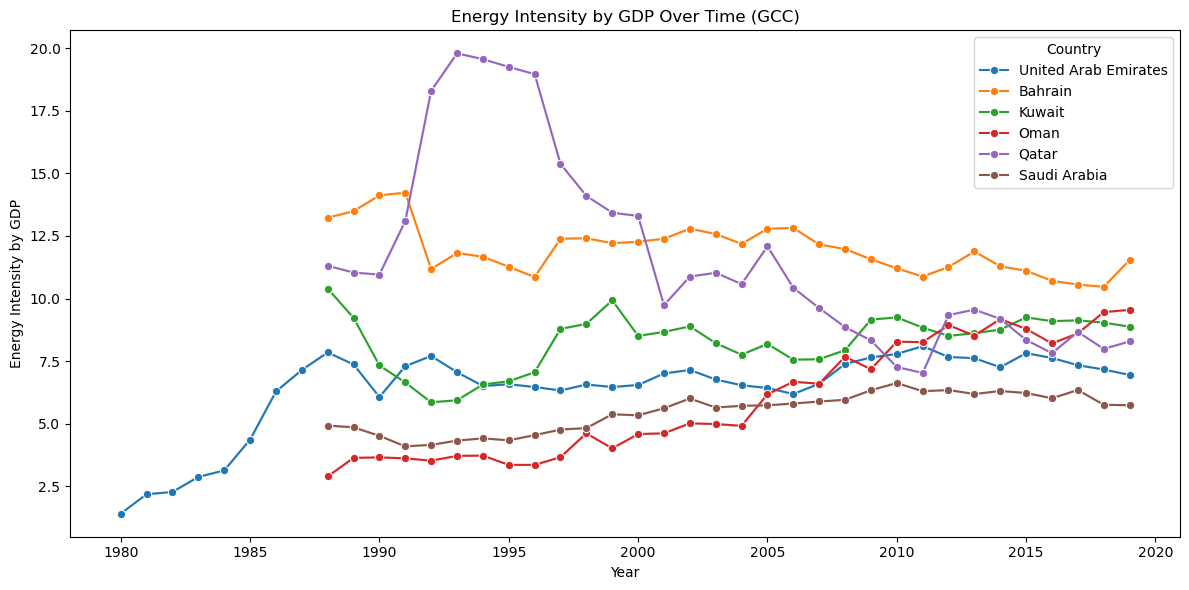

In [78]:
df_gcc = df_co[df_co['Country'].isin(gcc_countries)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_gcc, x='Year', y='Energy_intensity_by_GDP', hue='Country', marker='o')
plt.title('Energy Intensity by GDP Over Time (GCC)')
plt.ylabel('Energy Intensity by GDP')
plt.xlabel('Year')
plt.tight_layout()
plt.show()


In [269]:
# Filter for GCC countries
gcc_countries = ['Bahrain', 'Kuwait', 'Oman', 'Qatar', 'Saudi Arabia', 'United Arab Emirates']
df_gcc = df_co[df_co['Country'].isin(gcc_countries)]

# Group by Year to analyze total emissions and GDP for GCC
df_gcc_grouped = df_gcc.groupby('Year').agg({
    'CO2_emission': 'sum',
    'GDP': 'sum',
    'Population': 'sum'
}).reset_index()

# Calculate per capita and GDP per capita for GCC
df_gcc_grouped['CO2_per_capita'] = df_gcc_grouped['CO2_emission'] / df_gcc_grouped['Population']
df_gcc_grouped['GDP_per_capita'] = df_gcc_grouped['GDP'] / df_gcc_grouped['Population']

# Find the year with the highest CO2 emissions in GCC
max_co2_gcc = df_gcc_grouped.loc[df_gcc_grouped['CO2_emission'].idxmax(), ['Year', 'CO2_emission']]

# Find the year with the highest GDP in GCC
max_gdp_gcc = df_gcc_grouped.loc[df_gcc_grouped['GDP'].idxmax(), ['Year', 'GDP']]

# Show recent trends in per capita values
last_years_gcc = df_gcc_grouped[['Year', 'CO2_per_capita', 'GDP_per_capita']].tail(5)

max_co2_gcc, max_gdp_gcc, last_years_gcc


(Year            2016.00
 CO2_emission    2455.57
 Name: 36, dtype: float64,
 Year     2019.00
 GDP     15370.15
 Name: 39, dtype: float64,
     Year  CO2_per_capita  GDP_per_capita
 35  2015        0.008917        0.056034
 36  2016        0.009166        0.055872
 37  2017        0.008600        0.054327
 38  2018        0.008375        0.054316
 39  2019        0.008090        0.053824)

### **Focus on Bahrain:**

10. How have Bahrain’s CO2 emissions and GDP changed over time?  
11. Has Bahrain improved its CO2 emissions per capita and energy intensity since 1980?  
12. How does Bahrain compare to other GCC countries and global averages?


In [82]:
bahrain_df = df_co[df_co['Country'] == 'Bahrain']

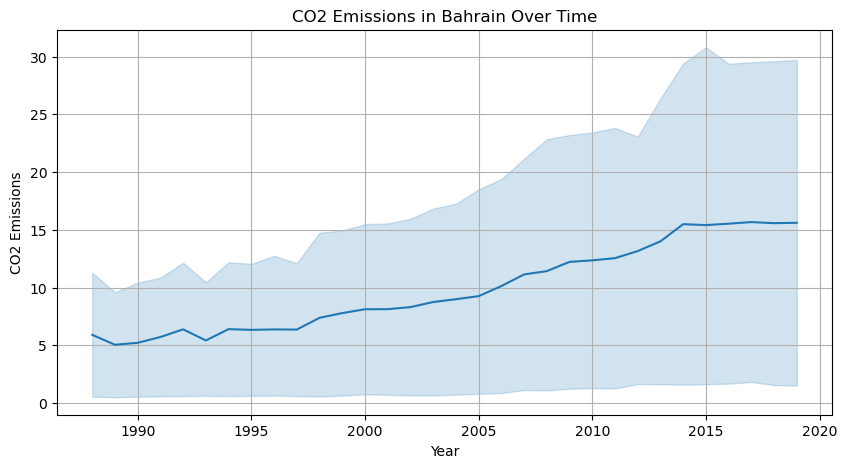

In [84]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=bahrain_df, x='Year', y='CO2_emission')
plt.title('CO2 Emissions in Bahrain Over Time')
plt.ylabel('CO2 Emissions')
plt.xlabel('Year')
plt.grid(True)
plt.show()


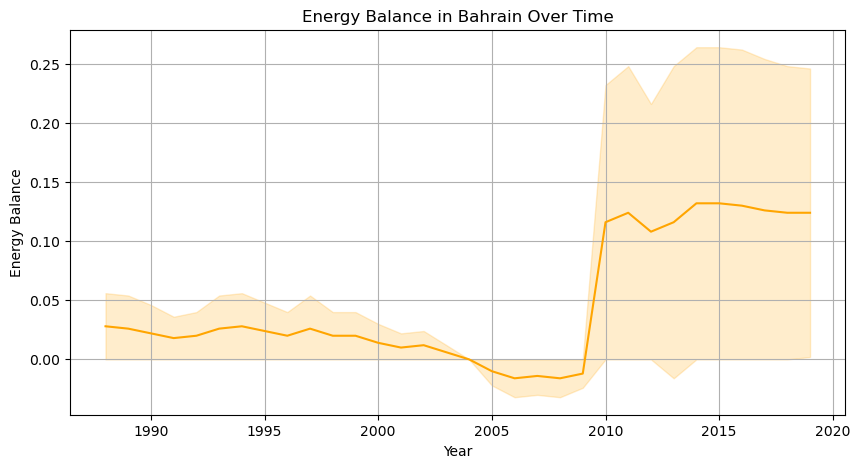

In [86]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=bahrain_df, x='Year', y='Energy_balance', color='orange')
plt.title('Energy Balance in Bahrain Over Time')
plt.ylabel('Energy Balance')
plt.xlabel('Year')
plt.grid(True)
plt.show()


C:\Users\97333\AppData\Local\Temp\ipykernel_20936\1862469665.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bahrain_df['CO2_per_GDP'] = bahrain_df['CO2_emission'] / bahrain_df['GDP']


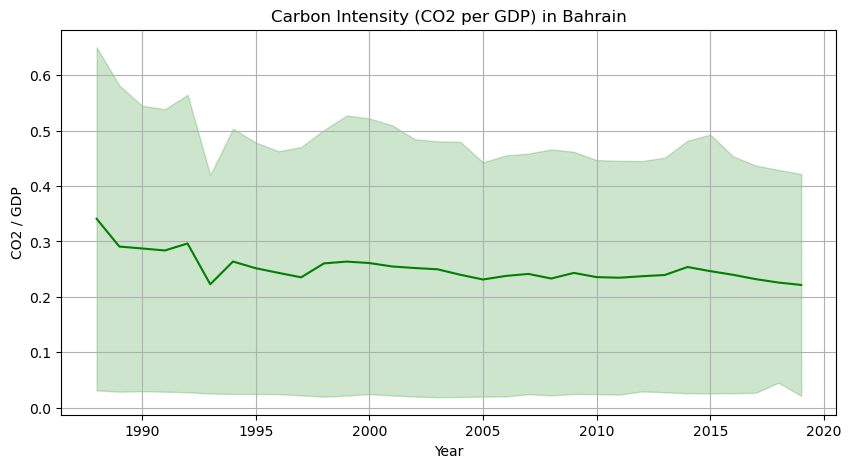

In [88]:
bahrain_df['CO2_per_GDP'] = bahrain_df['CO2_emission'] / bahrain_df['GDP']

plt.figure(figsize=(10, 5))
sns.lineplot(data=bahrain_df, x='Year', y='CO2_per_GDP', color='green')
plt.title('Carbon Intensity (CO2 per GDP) in Bahrain')
plt.ylabel('CO2 / GDP')
plt.xlabel('Year')
plt.grid(True)
plt.show()


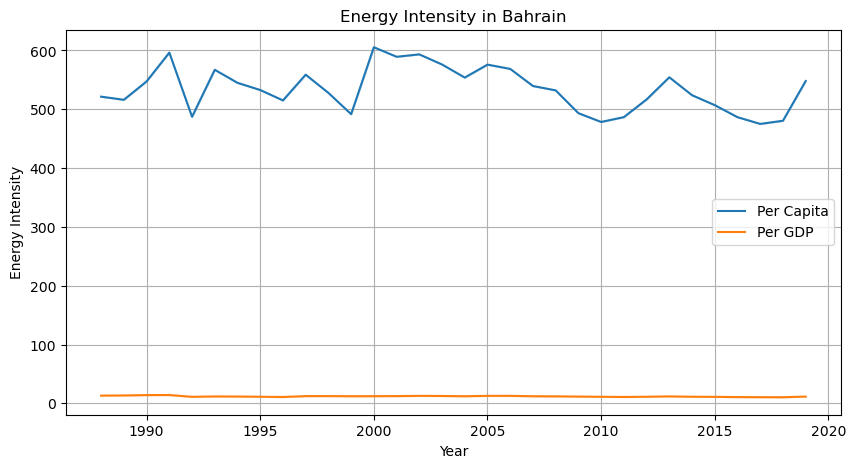

In [90]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=bahrain_df, x='Year', y='Energy_intensity_per_capita', label='Per Capita')
sns.lineplot(data=bahrain_df, x='Year', y='Energy_intensity_by_GDP', label='Per GDP')
plt.title('Energy Intensity in Bahrain')
plt.ylabel('Energy Intensity')
plt.xlabel('Year')
plt.legend()
plt.grid(True)
plt.show()


#### Q10:How have Bahrain’s CO2 emissions and GDP changed over time? 

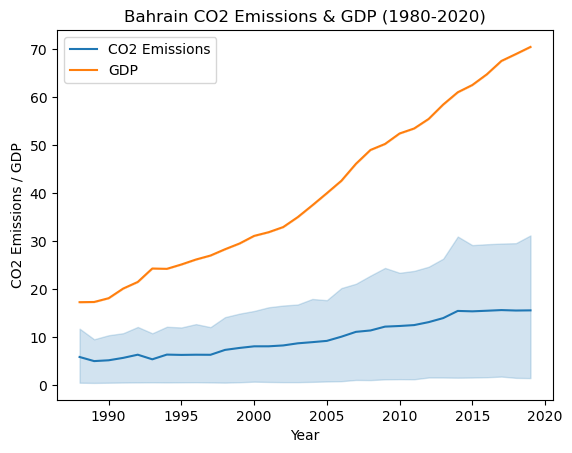

In [223]:
bahrain_data = df_co[df_co['Country'] == 'Bahrain']
sns.lineplot(x='Year', y='CO2_emission', data=bahrain_data, label='CO2 Emissions')
sns.lineplot(x='Year', y='GDP', data=bahrain_data, label='GDP')
plt.title('Bahrain CO2 Emissions & GDP (1980-2020)')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions / GDP')
plt.legend()
plt.show()


#### Q11:Has Bahrain improved its CO2 emissions per capita and energy intensity since 1980?   

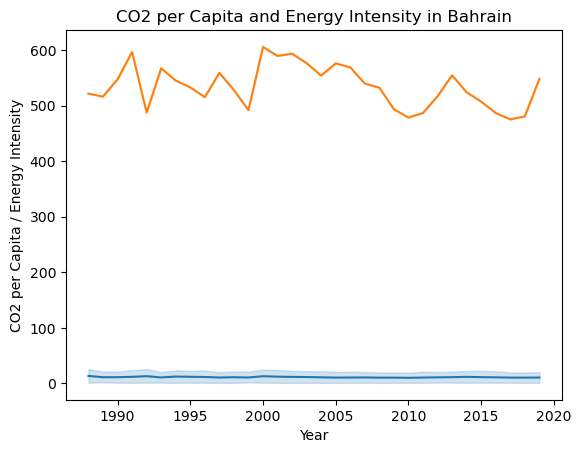

In [225]:
sns.lineplot(x='Year', y='CO2_per_capita', data=bahrain_data)
sns.lineplot(x='Year', y='Energy_intensity_per_capita', data=bahrain_data)
plt.title('CO2 per Capita and Energy Intensity in Bahrain')
plt.xlabel('Year')
plt.ylabel('CO2 per Capita / Energy Intensity')
plt.show()


In [271]:
# فلترة بيانات البحرين
df_bahrain = df_co[df_co['Country'] == 'Bahrain']

# تجميع البيانات حسب السنة
df_bahrain_grouped = df_bahrain.groupby('Year').agg({
    'CO2_emission': 'sum',
    'GDP': 'sum',
    'Population': 'sum'
}).reset_index()

# حساب القيم للفرد
df_bahrain_grouped['CO2_per_capita'] = df_bahrain_grouped['CO2_emission'] / df_bahrain_grouped['Population']
df_bahrain_grouped['GDP_per_capita'] = df_bahrain_grouped['GDP'] / df_bahrain_grouped['Population']

# استخراج أعلى سنة لانبعاثات CO2
max_co2_bahrain = df_bahrain_grouped.loc[df_bahrain_grouped['CO2_emission'].idxmax(), ['Year', 'CO2_emission']]
print("أعلى سنة في CO2:", max_co2_bahrain)

# استخراج أعلى سنة في الناتج المحلي
max_gdp_bahrain = df_bahrain_grouped.loc[df_bahrain_grouped['GDP'].idxmax(), ['Year', 'GDP']]
print("أعلى سنة في GDP:", max_gdp_bahrain)

# عرض آخر 5 سنوات للفرد
print(df_bahrain_grouped[['Year', 'CO2_per_capita', 'GDP_per_capita']].tail(5))
_

أعلى سنة في CO2: Year            2017.00
CO2_emission      78.32
Name: 29, dtype: float64
أعلى سنة في GDP: Year    2019.00
GDP      352.25
Name: 31, dtype: float64
    Year  CO2_per_capita  GDP_per_capita
27  2015        0.011241        0.045624
28  2016        0.010899        0.045447
29  2017        0.010435        0.044986
30  2018        0.010360        0.045885
31  2019        0.010517        0.047481


0.0

#### Q12:How does Bahrain compare to other GCC countries and global averages?

###  **Cross-Cutting / Storytelling Support📊**

13. Is there a consistent relationship between GDP and CO2 emissions across different income or energy-producing groups (e.g., high-income vs. low-income countries, fossil fuel exporters vs. importers)?  
14. Do countries with large energy surpluses always have stronger economies?  
15. Can we use historical trends to forecast future CO2 emissions for countries like Bahrain?


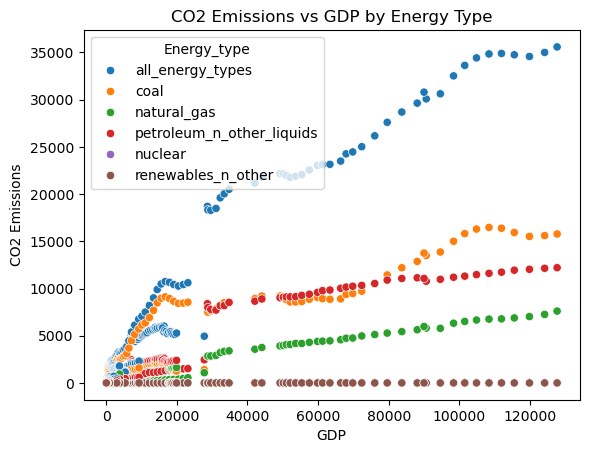

In [243]:
sns.scatterplot(x='GDP', y='CO2_emission', data=df_co, hue='Energy_type')
plt.title('CO2 Emissions vs GDP by Energy Type')
plt.xlabel('GDP')
plt.ylabel('CO2 Emissions')
plt.show()


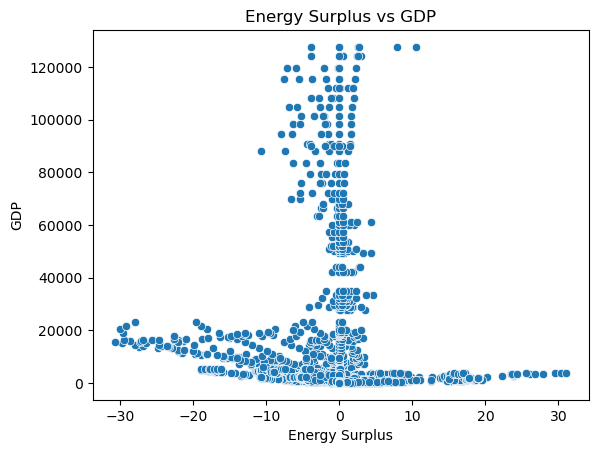

In [247]:
sns.scatterplot(x='Energy_balance', y='GDP', data=df_co)
plt.title('Energy Surplus vs GDP')
plt.xlabel('Energy Surplus')
plt.ylabel('GDP')
plt.show()


C:\Users\97333\AppData\Local\Temp\ipykernel_20936\3540459882.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


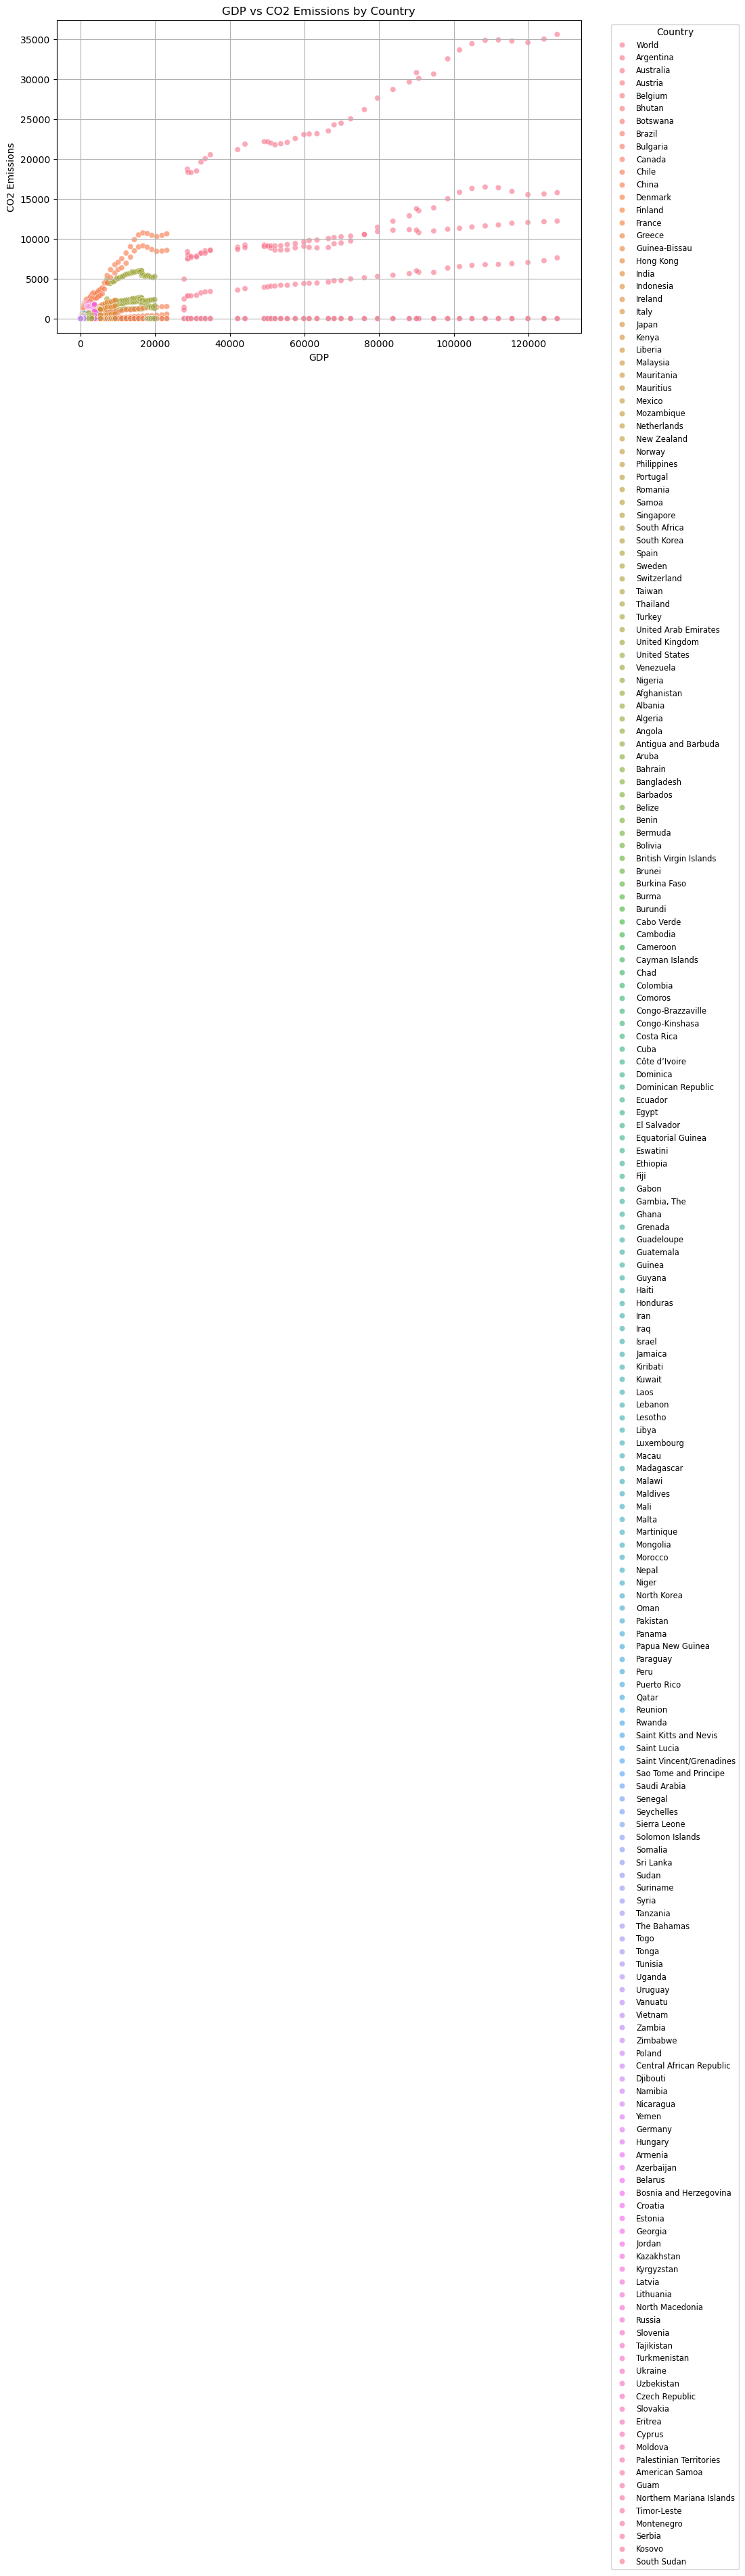

In [93]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_co, x='GDP', y='CO2_emission', hue='Country', alpha=0.6)
plt.title('GDP vs CO2 Emissions by Country')
plt.xlabel('GDP')
plt.ylabel('CO2 Emissions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Country', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

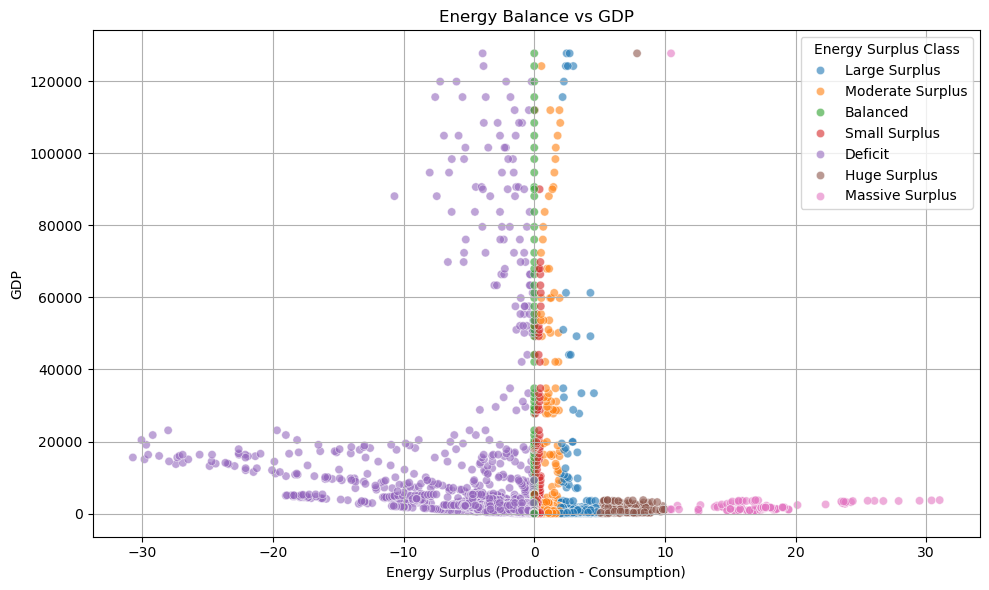

                Energy_balance       GDP
Energy_balance        1.000000 -0.107351
GDP                  -0.107351  1.000000


In [95]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_co, x='Energy_balance', y='GDP', hue='Energy_Surplus_Class', alpha=0.6)
plt.title('Energy Balance vs GDP')
plt.xlabel('Energy Surplus (Production - Consumption)')
plt.ylabel('GDP')
plt.grid(True)
plt.legend(title='Energy Surplus Class')
plt.tight_layout()
plt.show()
print(df_co[['Energy_balance', 'GDP']].corr())


C:\Users\97333\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\97333\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\97333\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\97333\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


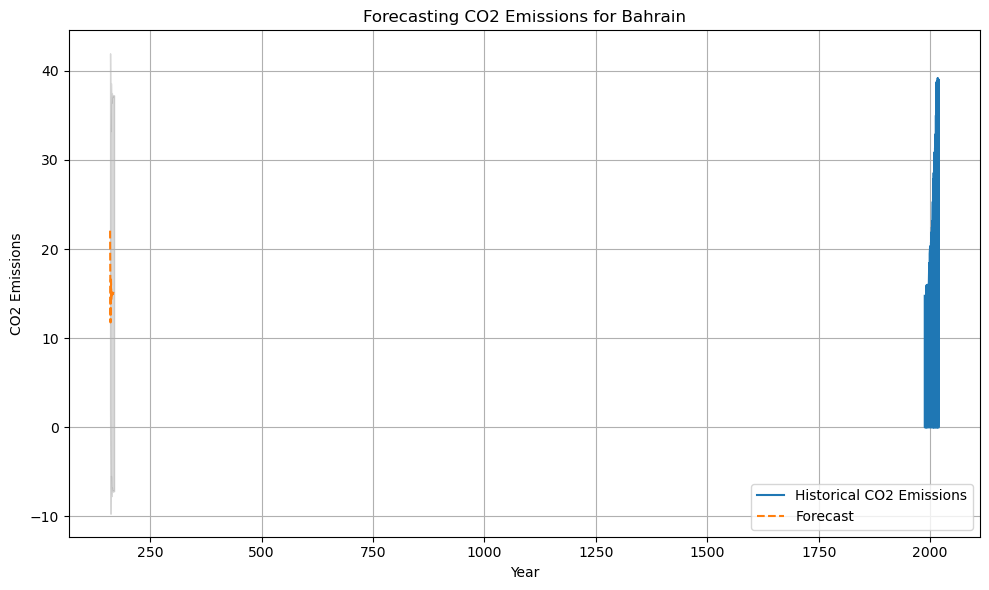

In [97]:
import statsmodels.api as sm

bahrain_df = df_co[df_co['Country'] == 'Bahrain'].sort_values('Year')
bahrain_ts = bahrain_df.set_index('Year')['CO2_emission']

model = sm.tsa.SARIMAX(bahrain_ts, order=(1,1,1), seasonal_order=(0,0,0,0))
results = model.fit()

forecast = results.get_forecast(steps=10)
predicted_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(10, 6))
plt.plot(bahrain_ts, label='Historical CO2 Emissions')
plt.plot(predicted_mean, label='Forecast', linestyle='--')
plt.fill_between(predicted_mean.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='gray', alpha=0.3)
plt.title('Forecasting CO2 Emissions for Bahrain')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [97]:
df_co.to_csv('Final_CO2_Energy_GDP.csv', index=False)